![Logo](LIS.jpg)

# Mathematical Fundamentals for Machine Learning
## Single-Variable Regression with Gradient Descent

In this notebook, we'll build up the mathematical tools needed to understand how a machine learning model learns. We'll do this by exploring the mathematics behind the simplest machine learning model: a regression estimator. This model assumes a linear relationship between a predictor variable, $X$, and a predicted variable, $Y$. 

We'll start with lines, then cost functions, then derivatives, and finally see how gradient descent uses derivatives to find the best-fitting line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import pandas as pd
import seaborn as sns
sns.set()

# Set random seed for reproducibility
np.random.seed(42)


## Part 1: The Equation of a Line

A line is a function that maps an input $x$ to an output $y$.

$$y = mx + b$$

- **m** is the slope: how steep the line is. It is defined as the amount by which the line rises on the vertical dimension for a unit change on the horizontal dimension ("the rise over the run") 
- **b** is the intercept: where the line crosses the y-axis. In other words, it is the value of $y$ when $x$ is 0.

![Logo](line_plot.png)

### Real world example: Marks obtained as a function of hours studied

Linear models are amongst the most common estimators in machine learning because so many phenomena in the natural and social environment can be explained in linear terms. That is, a change in the predictor variable, $X$, always leads to a proprtionally similar change in the predicted variable, $Y$. But not all phenomena are linear like this! In some cases, $Y$ might scale in proportion to $X^2$ or $X^3$; these are non-linear models. We'll cover these later.

Let's start with simple example: marks obtained in an exam relative to hours of study.

![Study](study_hours.png)

It's clear that there is a linear relationship between the hours studied and the marks obtained: students who study more hours get more marks. But what's less clear is the specific linear model that best fits this data. In practice, this means we need to find the line of best fit––that is, the line with an intercept and slope that minimizes the distance from the observations. This is a <b>two parameter</b> model. What are these parameters? The slope (m) and the intercept (b)

![parameters](parameters.png)

## Part 2: The Cost Function (Mean Squared Error)

So, we know we want the line that fits it best. But what does "best" mean?

We define a **cost function** that measures how badly a line fits the data. We'll use **Mean Squared Error (MSE)**; this gives the square of the difference between the data, $y_{i}$, we observe for a given input $x_{i}$, and the data our linear model predicts, represented as $\hat{y}_{i}$. This difference is called a <i>residual</i> and is shown by red dotted lines below. In sum, then, for a given observation, $y_{i}$:

$$MSE = (y_{i} - \hat{y}_{i})^2$$

![Study](MSE_residuals.png)

However, because $\hat{y}_{i}$ is a prediction of our model, we can say:

$$MSE = (y_{i} - (mx_i + b))^2$$

If we get the average MSE across all the $n$ observations that make up our data, we then get the <i>cost function</i>, which tells us how much information we lost by using this model to estimate the data.

$$\text{Cost}(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + b))^2$$

Where:
- $(x_i, y_i)$ are our data points
- $(mx_i + b)$ is our prediction for $x_i$
- We square the errors to penalize large mistakes and avoid negatives canceling positives
- A lower cost means a better fit

What does this look like in practice?

![fitted](fitted_lines.png)

## Part 3: Derivatives

A **derivative** measures how much a function changes when you nudge its input slightly.

$$\frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Intuitively: it's the **slope** of the function at that point.

![Tangents](tangents.jpg)

### Rules for computing derivatives

**Power rule:** If $f(x) = x^n$, then $\frac{df}{dx} = nx^{n-1}$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Example: If $f(x) = x^3$, then $\frac{df}{dx} = 3x^2$

**Sum rule:** If $f(x) = g(x) + h(x)$, then $\frac{df}{dx} = \frac{dg}{dx} + \frac{dh}{dx}$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Example: If $f(x) = x^2 + x$, then $\frac{df}{dx} = 2x + 1$

**Constant multiple:** If $f(x) = c \cdot g(x)$, then $\frac{df}{dx} = c \cdot \frac{dg}{dx}$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Example: If $f(x) = 5x^2$, then $\frac{df}{dx} = 5 \cdot 2x = 10x$

### The value of a derivative for a cost function

When a derivative equals 0, this means the tangent line is flat: it's either a maximum or a minimum point. This allows us to quickly find where the cost function is smallest, thereby giving a target for finding the right parameters.

![min_max](min_max.png)

Key insights:
1. The derivative is the slope at a point.
2. Where the derivative = 0, the function reaches a minimum or maximum.
3. For our cost function, where Cost'(m) = 0 is where we find the best **m**, and our cost function where Cost'(b) = 0 gives our best **b**.

![two_param](two_param.png)

## Part 4: Gradient Descent

Sometimes we can calculate the , we can use an iterative algorithm called **gradient descent**.

The idea: 
1. Start with a guess for m and b
2. Compute the derivatives ∂Cost/∂m and ∂Cost/∂b
3. Take a small step in the direction opposite to the gradient
4. Repeat until the cost stops decreasing

The update rule is:
$$m_{\text{new}} = m_{\text{old}} - \alpha \cdot \frac{\partial \text{Cost}}{\partial m}$$
$$b_{\text{new}} = b_{\text{old}} - \alpha \cdot \frac{\partial \text{Cost}}{\partial b}$$

Where $\alpha$ (alpha) is the **learning rate**: how big a step we take. Too small = slow learning. Too big = might overshoot.

![gradient](gradient.png)

## Summary

We've built up the key ideas for single-variable regression:

1. **The line:** A function y = mx + b with parameters we want to optimize
2. **The cost function:** Measures how badly our line fits the data (Mean Squared Error)
3. **Derivatives:** Tell us the slope of the cost function—which direction to move our parameters
4. **Gradient descent:** An iterative algorithm that uses derivatives to step downhill toward the optimal parameters

This same pattern—cost function + derivatives + gradient descent—is how neural networks learn too. In that case, the functions are more complex (many parameters, nonlinear), but the core idea is identical.

## Fitting a regression model in python

In [5]:
data = pd.read_csv("student_marks.csv")
data.head()

,hours_studied,marks
0,0.08,26.6
1,0.10,31.4
2,0.25,48.0
3,0.31,40.8
4,0.38,21.8


<Axes: xlabel='hours_studied', ylabel='marks'>

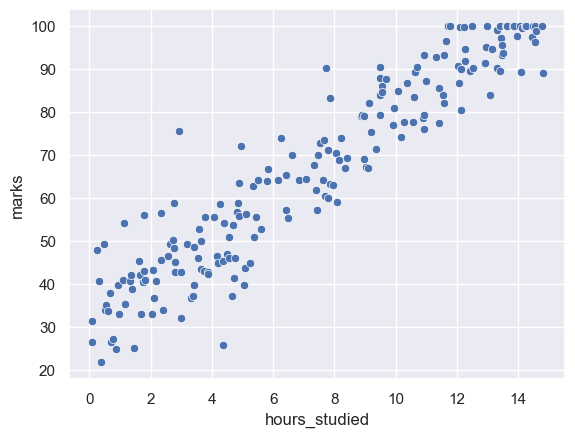

In [168]:
sns.scatterplot(x = "hours_studied", y = "marks", data = data)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# Create sample data
X = data['hours_studied'].values.reshape(-1, 1) # Reshaping is done because sklearn expects several predictor variables
y = data['marks']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Make predictions
predictions = model.predict([[6], [7]])

In [182]:
print("Coefficients (slope):", model.coef_)          # array of coefficients
print("Intercept:", model.intercept_)               # intercept term
print("Number of features:", model.n_features_in_) # number of predictor variables

Coefficients (slope): [4.82589531]
Intercept: 31.42374137160771
Number of features: 1


## Evaluating model fit

We typically want to know how well our model fits our data in proportional terms. That is, where 1 is a perfect fit and 0 is no fit at all, where our model sits. We calculate this using a measure known as the $R^2$ score. Its formula is:

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Where:
- $y_i$ = observed value for sample $i$
- $\hat{y}_i$ = predicted value for sample $i$
- $\bar{y}$ = mean of all observed values
- $n$ = number of samples
- $\text{SS}_{\text{res}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$ = sum of squared residuals
- $\text{SS}_{\text{tot}} = \sum_{i=1}^{n} (y_i - \bar{y})^2$ = total sum of squares


In [8]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Evaluate model fit
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Make predictions
predictions = model.predict([[6], [7]])
print(f"\nPredicted marks for 6 hours: {predictions[0]:.1f}")
print(f"Predicted marks for 7 hours: {predictions[1]:.1f}")

R²: 0.8888
RMSE: 7.53
Slope: 4.8259
Intercept: 31.4237

Predicted marks for 6 hours: 60.4
Predicted marks for 7 hours: 65.2
